In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-06-05 13:38:00.278483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780666680.467752      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780666680.527094      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780666680.999894      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780666680.999938      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780666680.999941      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if "PlantVillage" in root:
        print(root)

/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Pepper__bell___Bacterial_spot
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Potato___healthy
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Tomato_Leaf_Mold
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Tomato_Bacterial_spot
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage/Tomato_Septoria_leaf_spot
/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVi

**Cell 1 - Imports**

In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers
from tensorflow.keras import models

**Cell 2 - Dataset Path**

In [15]:
dataset_path = "/kaggle/input/datasets/maheshdattatreya/research-question-1/archive (3)/PlantVillage/PlantVillage"

print("Exists:", os.path.exists(dataset_path))
print("Classes:", len(os.listdir(dataset_path)))

Exists: True
Classes: 15


**Cell 3 - Load Dataset**

In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", num_classes)
print(class_names)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Number of Classes:", len(class_names))

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Number of Classes: 15


**Cell 4 - Performance Optimisation**

In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

**Cell 5 - Display Sample Images**

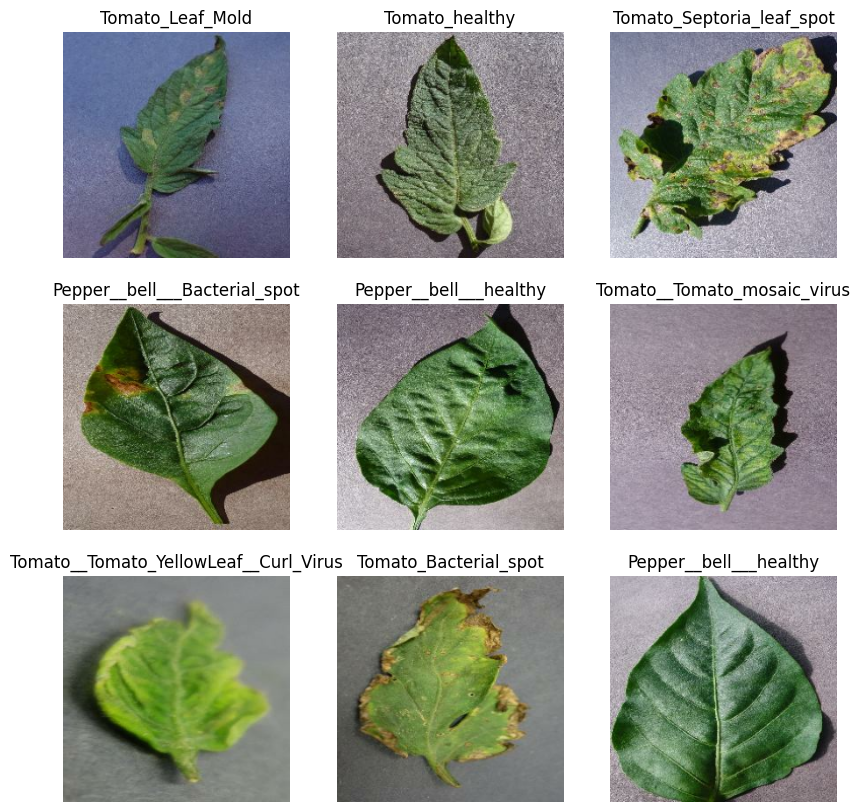

In [18]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

**Cell 6: Function to Measure Metrics**

In [20]:
results = []

def evaluate_model(model, model_name):

    start = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    training_time = time.time() - start

    loss, accuracy = model.evaluate(val_ds, verbose=0)

    params = model.count_params()

    model.save(f"{model_name}.keras")

    size_mb = os.path.getsize(f"{model_name}.keras")/(1024*1024)

    power_watts = 70
    energy_wh = power_watts * (training_time/3600)

    results.append([
        model_name,
        accuracy,
        params,
        size_mb,
        training_time,
        energy_wh
    ])

    return history

**Cell 7: Baseline CNN**

In [21]:
cnn_model = models.Sequential([

    layers.Rescaling(1./255,
                     input_shape=(224,224,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dense(len(class_names),
                 activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Cell 8: Train CNN**

In [22]:
cnn_history = evaluate_model(
    cnn_model,
    "Baseline_CNN"
)

Epoch 1/5


I0000 00:00:1780667730.878347     162 service.cc:152] XLA service 0x7de164005f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780667730.878403     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780667730.878410     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780667731.252495     162 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-05 13:55:33.784698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 13:55:33.933488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/516 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.1198 - loss: 3.6641  

I0000 00:00:1780667736.639692     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


289/516 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.3583 - loss: 2.0502

2026-06-05 13:55:52.379150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 13:55:52.527635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


516/516 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.6345 - loss: 1.1305 - val_accuracy: 0.8117 - val_loss: 0.5578
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.8446 - loss: 0.4624 - val_accuracy: 0.8326 - val_loss: 0.5221
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9072 - loss: 0.2745 - val_accuracy: 0.8854 - val_loss: 0.3351
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9432 - loss: 0.1739 - val_accuracy: 0.8360 - val_loss: 0.5272
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9606 - loss: 0.1150 - val_accuracy: 0.8861 - val_loss: 0.4035


**Cell 9: MobileNetV2**

In [28]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

base_model.trainable = False

mobilenet_model = tf.keras.Sequential([
    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

**Cell 10: Train MobileNetV2**

In [ ]:
mobilenet_history = evaluate_model(
    mobilenet_model,
    "MobileNetV2"
)

**Cell 11: EfficientNetB0**

In [29]:
base_model = tf.keras.applications.EfficientNetB0(

    input_shape=(224,224,3),

    include_top=False,

    weights='imagenet'
)

base_model.trainable = False

efficientnet_model = tf.keras.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**Cell 12: Train EfficientNetB0**

In [30]:
efficientnet_history = evaluate_model(
    efficientnet_model,
    "EfficientNetB0"
)

Epoch 1/5


2026-06-05 14:06:46.838689: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:06:46.982618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:06:47.341698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:06:47.485022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:06:48.403266: E external/local_xla/xla/stream_

515/516 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6682 - loss: 1.2487

2026-06-05 14:07:21.523140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:07:21.666609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:07:22.019572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:07:22.161814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-05 14:07:23.031090: E external/local_xla/xla/stream_

516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 96ms/step - accuracy: 0.8015 - loss: 0.7899 - val_accuracy: 0.8999 - val_loss: 0.3907
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.9131 - loss: 0.3327 - val_accuracy: 0.9307 - val_loss: 0.2682
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.9365 - loss: 0.2462 - val_accuracy: 0.9435 - val_loss: 0.2141
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9475 - loss: 0.2009 - val_accuracy: 0.9525 - val_loss: 0.1828
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9543 - loss: 0.1740 - val_accuracy: 0.9542 - val_loss: 0.1654


**Cell 13: Create Results Table**

In [31]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Parameters",
        "Size_MB",
        "Training_Time_sec",
        "Energy_Wh"
    ]
)

results_df["Efficiency"] = (
    results_df["Accuracy"] /
    results_df["Energy_Wh"]
)

results_df

,Model,Accuracy,Parameters,Size_MB,Training_Time_sec,Energy_Wh,Efficiency
0,Baseline_CNN,0.886116,11170895,127.886161,157.357851,3.059736,0.289605
1,EfficientNetB0,0.954204,4068786,16.470125,163.667687,3.182427,0.299835


**Cell 14: Accuracy Comparison**

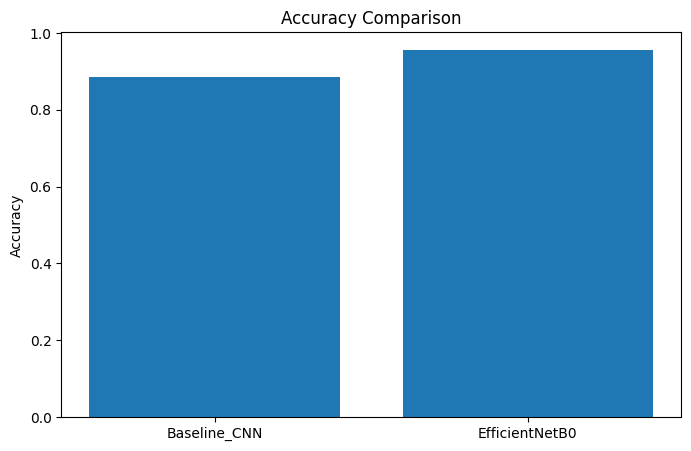

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison"
)

plt.show()

**Cell 15: Energy Consumption Comparison**

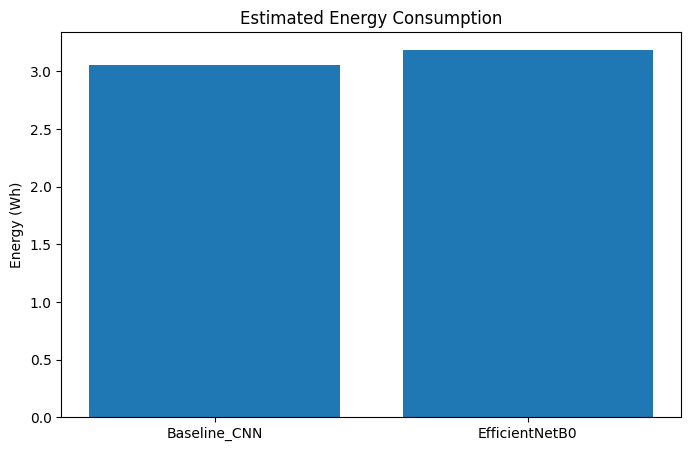

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Energy_Wh"]
)

plt.ylabel("Energy (Wh)")

plt.title(
    "Estimated Energy Consumption"
)

plt.show()

**Cell 16: Sustainability Trade-off Plot**

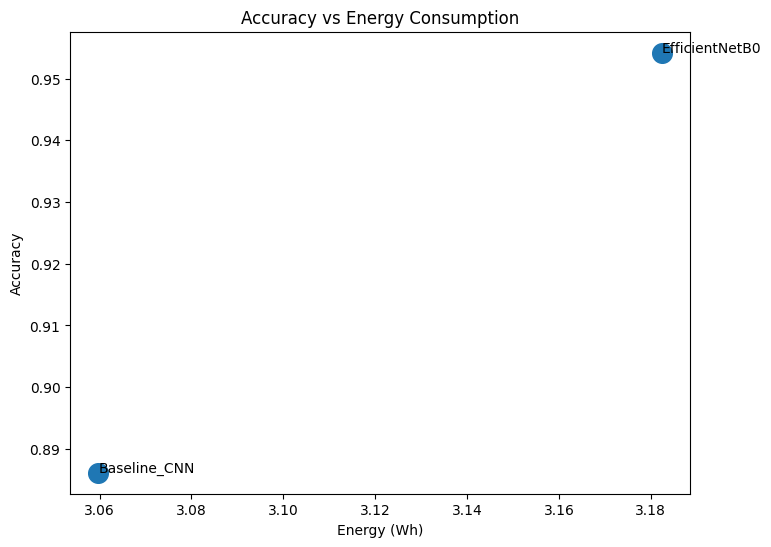

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    results_df["Energy_Wh"],
    results_df["Accuracy"],
    s=200
)

for i,row in results_df.iterrows():
    plt.annotate(
        row["Model"],
        (row["Energy_Wh"],
         row["Accuracy"])
    )

plt.xlabel("Energy (Wh)")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs Energy Consumption"
)

plt.show()